In [4]:
import os
import math

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from copy import deepcopy

# GPU-only execution.
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. This notebook is configured for GPU-only execution.")

device = torch.device("cuda")
torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

TARGET_SIZE = 64
BATCH_SIZE = 32
HIDDEN_DIM = 64
NUM_LAYERS = 2
DROPOUT = 0.5
LR = 1e-3
MAX_EPOCHS = 30
PATIENCE = 8
NUM_WORKERS = 0

def build_grid_graph(size: int):
    offsets = [
        (-1, -1, 1.0 / math.sqrt(2.0)),
        (-1, 0, 1.0),
        (-1, 1, 1.0 / math.sqrt(2.0)),
        (0, -1, 1.0),
        (0, 1, 1.0),
        (1, -1, 1.0 / math.sqrt(2.0)),
        (1, 0, 1.0),
        (1, 1, 1.0 / math.sqrt(2.0)),
    ]
    sources = []
    targets = []
    weights = []

    for row in range(size):
        for col in range(size):
            source = row * size + col
            for d_row, d_col, weight in offsets:
                next_row = row + d_row
                next_col = col + d_col
                if 0 <= next_row < size and 0 <= next_col < size:
                    target = next_row * size + next_col
                    sources.append(source)
                    targets.append(target)
                    weights.append(weight)

    edge_index = torch.tensor([sources, targets], dtype=torch.long)
    edge_attr = torch.tensor(weights, dtype=torch.float32)
    return edge_index, edge_attr


EDGE_INDEX, EDGE_ATTR = build_grid_graph(TARGET_SIZE)

# Load existing .npy files
train_x = np.load("train_pixel_graphs.npy")
train_y_raw = np.load("train_labels.npy", allow_pickle=True)

val_x = np.load("val_pixel_graphs.npy")
val_y_raw = np.load("val_labels.npy", allow_pickle=True)

test_x = np.load("test_pixel_graphs.npy")
test_y_raw = np.load("test_labels.npy", allow_pickle=True)

# Encode labels
all_labels = np.concatenate([train_y_raw, val_y_raw, test_y_raw])
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)
num_classes = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))

train_y_encoded = label_encoder.transform(train_y_raw)
val_y_encoded = label_encoder.transform(val_y_raw)
test_y_encoded = label_encoder.transform(test_y_raw)

class PrecomputedGraphDataset(torch.utils.data.Dataset):
    def __init__(self, x_data, y_data):
        self.x_data = x_data
        self.y_data = y_data

    def __len__(self):
        return len(self.y_data)

    def __getitem__(self, idx):
        x = torch.tensor(self.x_data[idx], dtype=torch.float32)
        y = torch.tensor(self.y_data[idx], dtype=torch.long)
        return Data(x=x, edge_index=EDGE_INDEX, edge_attr=EDGE_ATTR, y=y)

train_dataset = PrecomputedGraphDataset(train_x, train_y_encoded)
val_dataset = PrecomputedGraphDataset(val_x, val_y_encoded)
test_dataset = PrecomputedGraphDataset(test_x, test_y_encoded)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


class SGCNLayer(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.5):
        super().__init__()
        self.conv = GCNConv(in_channels, out_channels)
        self.bn = nn.BatchNorm1d(out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr=None):
        x = self.conv(x, edge_index, edge_weight=edge_attr)
        x = self.bn(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x


class SGCN(nn.Module):
    def __init__(self, in_channels, num_classes, hidden_dim=64, num_layers=2, dropout=0.5):
        super().__init__()
        self.layers = nn.ModuleList()
        for layer_idx in range(num_layers):
            self.layers.append(
                SGCNLayer(
                    in_channels if layer_idx == 0 else hidden_dim,
                    hidden_dim,
                    dropout=dropout,
                )
            )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_attr = getattr(data, "edge_attr", None)
        batch = getattr(data, "batch", None)

        for layer in self.layers:
            x = layer(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)
        return self.classifier(x)


model = SGCN(
    in_channels=8,
    num_classes=num_classes,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()


def run_epoch(loader, training: bool):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for batch in loader:
        batch = batch.to(device)
        targets = batch.y.view(-1)

        if training:
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                logits = model(batch)
                loss = criterion(logits, targets)

        total_loss += loss.item() * targets.size(0)
        predictions = logits.argmax(dim=1)
        all_preds.extend(predictions.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    return avg_loss, accuracy, macro_f1


best_state = None
best_val_f1 = -1.0
patience_left = PATIENCE
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc, train_f1 = run_epoch(train_loader, training=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, training=False)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = deepcopy(model.state_dict())
        patience_left = PATIENCE
    else:
        patience_left -= 1
        if patience_left == 0:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_state)
test_loss, test_acc, test_f1 = run_epoch(test_loader, training=False)

print("\nFinal test results")
print(f"Loss    : {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"Macro-F1: {test_f1:.4f}")

model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        logits = model(batch)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy().tolist())
        all_targets.extend(batch.y.view(-1).cpu().numpy().tolist())

pred_labels = label_encoder.inverse_transform(np.asarray(all_preds))
target_labels = label_encoder.inverse_transform(np.asarray(all_targets))
print("\nClassification report (test):")
print(classification_report(target_labels, pred_labels, digits=4))

Using device: cuda
Classes: [np.str_('autorickshaw'), np.str_('bus'), np.str_('car'), np.str_('mini-bus'), np.str_('motorcycle'), np.str_('scooter'), np.str_('truck')]
Epoch 01 | train loss 1.4229 acc 0.4695 f1 0.2452 | val loss 1.2165 acc 0.5471 f1 0.2978
Epoch 02 | train loss 1.2283 acc 0.5405 f1 0.2948 | val loss 1.1213 acc 0.5813 f1 0.3087
Epoch 03 | train loss 1.1766 acc 0.5618 f1 0.3233 | val loss 1.1196 acc 0.5761 f1 0.3445
Epoch 04 | train loss 1.1457 acc 0.5722 f1 0.3523 | val loss 1.0709 acc 0.5823 f1 0.3398
Epoch 05 | train loss 1.1235 acc 0.5802 f1 0.3603 | val loss 1.0562 acc 0.5955 f1 0.3723
Epoch 06 | train loss 1.1113 acc 0.5818 f1 0.3695 | val loss 1.0221 acc 0.6051 f1 0.3759
Epoch 07 | train loss 1.1031 acc 0.5866 f1 0.3832 | val loss 1.0412 acc 0.6025 f1 0.3849
Epoch 08 | train loss 1.0839 acc 0.5907 f1 0.3884 | val loss 1.0095 acc 0.6145 f1 0.4092
Epoch 09 | train loss 1.0593 acc 0.5983 f1 0.4051 | val loss 0.9974 acc 0.6189 f1 0.4157
Epoch 10 | train loss 1.0597 ac

/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [5]:
# Quick check: infer hierarchy depth encoded in labels used by Cell 1
import numpy as np

def label_depth(v):
    return len(str(v).split('_'))

all_raw = np.concatenate([train_y_raw, val_y_raw, test_y_raw])
all_raw = np.asarray([str(v) for v in all_raw])

depths = np.asarray([label_depth(v) for v in all_raw])
unique_depths, counts = np.unique(depths, return_counts=True)

print('Unique labels:', len(np.unique(all_raw)))
print('Depth distribution:', {int(d): int(c) for d, c in zip(unique_depths, counts)})
print('Sample labels:', np.unique(all_raw)[:20])

if len(unique_depths) == 1:
    d = int(unique_depths[0])
    if d == 1:
        print('=> Cell 1 corresponds to L1 only (single token labels).')
    elif d == 2:
        print('=> Cell 1 corresponds to L2 only (two-token labels).')
    elif d >= 3:
        print('=> Cell 1 corresponds to L3/fine-level labels (>=3 tokens).')
else:
    print('=> Mixed label depths found. Cell 1 is not a clean single hierarchy level.')

Unique labels: 7
Depth distribution: {1: 24449}
Sample labels: ['autorickshaw' 'bus' 'car' 'mini-bus' 'motorcycle' 'scooter' 'truck']
=> Cell 1 corresponds to L1 only (single token labels).


In [ ]:
# FGVD Paper-Aligned SGCN Training
# ========================================
# Load the properly structured graph data from FGVD_Graph_Handover
# Reproduces L1, L2, L3 classification with exact paper hyperparameters

import numpy as np
import pandas as pd
import scipy.sparse as sp
from pathlib import Path
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

# GPU setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ────────────────────────────────────────────────────
# LOAD DATA
# ────────────────────────────────────────────────────
data_root = Path("FGVD_Graph_Handover")
metadata_path = data_root / "metadata.csv"
adj_path = data_root / "master_grid_adj.npz"
features_root = data_root / "raw_features"

# Load metadata
metadata = pd.read_csv(metadata_path)
print(f"Loaded {len(metadata)} vehicle samples from metadata")
print(f"Columns: {list(metadata.columns)}")
print(f"Splits: {metadata['split'].value_counts().to_dict()}")

# Load adjacency matrix
adj_sparse = sp.load_npz(adj_path)
print(f"Adjacency matrix shape: {adj_sparse.shape}")

# Convert adjacency to edge_index and edge_attr for PyG
adj_coo = adj_sparse.tocoo()
edge_index = torch.tensor(np.vstack([adj_coo.row, adj_coo.col]), dtype=torch.long)
edge_attr = torch.tensor(adj_coo.data, dtype=torch.float32)
print(f"Edge index shape: {edge_index.shape}, Edge attr shape: {edge_attr.shape}")

# ────────────────────────────────────────────────────
# FEATURE LOADING & STACKING
# ────────────────────────────────────────────────────
def load_stacked_features(vehicle_id, split, level="L1"):
    """
    Load and stack RGB, Gabor, Sobel features for a vehicle.
    L1: RGB(3) + Gabor(4) + Sobel(1) = 8 channels
    L2/L3: RGB(3) + Gabor(4) = 7 channels
    """
    rgb   = np.load(features_root / "rgb" / split / f"{vehicle_id}.npy").astype(np.float32)
    gabor = np.load(features_root / "gabor" / split / f"{vehicle_id}.npy").astype(np.float32)
    
    if level == "L1":
        sobel = np.load(features_root / "sobel" / split / f"{vehicle_id}.npy").astype(np.float32)
        return np.concatenate([rgb, gabor, sobel], axis=1)  # (4096, 8)
    else:  # L2, L3
        return np.concatenate([rgb, gabor], axis=1)  # (4096, 7)

# ────────────────────────────────────────────────────
# DATASET CLASS
# ────────────────────────────────────────────────────
class FGVDGraphDataset(torch.utils.data.Dataset):
    def __init__(self, metadata_df, level="L1"):
        self.metadata = metadata_df.reset_index(drop=True)
        self.level = level
        
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        vehicle_id = row['vehicle_id']
        split = row['split']
        label_col = row[self.level]  # L1, L2, or L3
        
        x = load_stacked_features(vehicle_id, split, self.level)
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(label_col, dtype=torch.long)
        
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# ────────────────────────────────────────────────────
# SGCN MODEL (same as before)
# ────────────────────────────────────────────────────
class SGCNLayer(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv = GCNConv(in_channels, out_channels)
        self.bn = nn.BatchNorm1d(out_channels)
        self.dropout = dropout
    
    def forward(self, x, edge_index, edge_attr=None):
        x = self.conv(x, edge_index, edge_weight=edge_attr)
        x = self.bn(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x

class SGCN(nn.Module):
    def __init__(self, in_channels, num_classes, hidden_dim=64, num_layers=2, dropout=0.5):
        super().__init__()
        self.layers = nn.ModuleList()
        for layer_idx in range(num_layers):
            self.layers.append(
                SGCNLayer(
                    in_channels if layer_idx == 0 else hidden_dim,
                    hidden_dim,
                    dropout=dropout,
                )
            )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_attr = getattr(data, "edge_attr", None)
        batch = getattr(data, "batch", None)
        
        for layer in self.layers:
            x = layer(x, edge_index, edge_attr)
        
        x = global_mean_pool(x, batch)
        return self.classifier(x)

# ────────────────────────────────────────────────────
# TRAINING FUNCTION
# ────────────────────────────────────────────────────
def train_sgcn_level(level="L1"):
    print(f"\n{'='*60}")
    print(f"Training SGCN for {level}")
    print(f"{'='*60}")
    
    # Prepare data
    metadata_encoded = metadata.copy()
    
    # Encode labels for this level
    label_col = level
    le = LabelEncoder()
    metadata_encoded[label_col] = le.fit_transform(metadata[label_col])
    
    num_classes = len(le.classes_)
    print(f"Classes: {list(le.classes_)}, Num classes: {num_classes}")
    
    # Create datasets
    train_df = metadata_encoded[metadata_encoded['split'] == 'train']
    val_df = metadata_encoded[metadata_encoded['split'] == 'val']
    test_df = metadata_encoded[metadata_encoded['split'] == 'test']
    
    train_dataset = FGVDGraphDataset(train_df, level)
    val_dataset = FGVDGraphDataset(val_df, level)
    test_dataset = FGVDGraphDataset(test_df, level)
    
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    
    # Create dataloaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    
    # Model setup
    in_channels = 8 if level == "L1" else 7
    model = SGCN(in_channels=in_channels, num_classes=num_classes, 
                  hidden_dim=64, num_layers=2, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    # Training loop
    best_state = None
    best_val_f1 = -1.0
    patience = 8
    
    for epoch in range(1, 101):
        # Train
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch)
            loss = criterion(logits, batch.y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch.y.size(0)
        
        train_loss /= len(train_dataset)
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                logits = model(batch)
                loss = criterion(logits, batch.y)
                val_loss += loss.item() * batch.y.size(0)
                preds = logits.argmax(dim=1)
                val_preds.extend(preds.cpu().numpy().tolist())
                val_targets.extend(batch.y.cpu().numpy().tolist())
        
        val_loss /= len(val_dataset)
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average="macro")
        
        if (epoch - 1) % 5 == 0:
            print(f"Epoch {epoch:02d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} val_acc {val_acc:.4f} val_f1 {val_f1:.4f}")
        
        # Early stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = deepcopy(model.state_dict())
            patience = 8
        else:
            patience -= 1
            if patience == 0:
                print(f"Early stopping at epoch {epoch}")
                break
    
    # Test evaluation
    model.load_state_dict(best_state)
    model.eval()
    test_preds, test_targets = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            logits = model(batch)
            preds = logits.argmax(dim=1)
            test_preds.extend(preds.cpu().numpy().tolist())
            test_targets.extend(batch.y.cpu().numpy().tolist())
    
    test_acc = accuracy_score(test_targets, test_preds)
    test_f1 = f1_score(test_targets, test_preds, average="macro")
    
    print(f"\n{level} Test Results:")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  Macro-F1: {test_f1:.4f}")
    print("\nClassification Report:")
    pred_labels = le.inverse_transform(np.asarray(test_preds))
    target_labels = le.inverse_transform(np.asarray(test_targets))
    print(classification_report(target_labels, pred_labels, digits=4))
    
    return {
        "level": level,
        "accuracy": test_acc,
        "macro_f1": test_f1,
        "num_classes": num_classes,
    }

# ────────────────────────────────────────────────────
# RUN EXPERIMENTS FOR ALL LEVELS
# ────────────────────────────────────────────────────
results = []
for level in ["L1", "L2", "L3"]:
    try:
        res = train_sgcn_level(level)
        results.append(res)
    except Exception as e:
        print(f"ERROR for {level}: {e}")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
for res in results:
    print(f"{res['level']}: Acc {res['accuracy']*100:.2f}% | F1 {res['macro_f1']*100:.2f}% | Classes {res['num_classes']}")

Using device: cuda
Loaded 24450 vehicle samples from metadata
Columns: ['vehicle_id', 'split', 'image_stem', 'obj_idx', 'class_name', 'L1', 'L2', 'L3', 'xmin', 'ymin', 'xmax', 'ymax', 'occluded', 'truncated']
Splits: {'train': 15702, 'test': 4891, 'val': 3857}
Adjacency matrix shape: (4096, 4096)
Edge index shape: torch.Size([2, 32004]), Edge attr shape: torch.Size([32004])

Training SGCN for L1
Classes: ['autorickshaw', 'bus', 'car', 'mini-bus', 'motorcycle', 'scooter', 'truck'], Num classes: 7
Train: 15702, Val: 3857, Test: 4891
Epoch 01 | train_loss 1.4136 | val_loss 1.3157 val_acc 0.5092 val_f1 0.2768
Epoch 06 | train_loss 1.1581 | val_loss 1.1524 val_acc 0.5707 val_f1 0.3740
Epoch 11 | train_loss 1.0993 | val_loss 1.0764 val_acc 0.5968 val_f1 0.4228
Epoch 16 | train_loss 1.0625 | val_loss 1.0259 val_acc 0.6173 val_f1 0.4377
Epoch 21 | train_loss 1.0402 | val_loss 1.0325 val_acc 0.6119 val_f1 0.4409
Early stopping at epoch 25

L1 Test Results:
  Accuracy: 0.6254
  Macro-F1: 0.4466


/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/anaconda3/envs/fgvd/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

Epoch 01 | train_loss 2.6552 | val_loss 2.3993 val_acc 0.2888 val_f1 0.0349
Epoch 06 | train_loss 2.3360 | val_loss 2.2872 val_acc 0.3065 val_f1 0.0436


KeyboardInterrupt: 

In [ ]:
# Paper-faithful SGCN runner for FGVD_Graph_Handover
# ----------------------------------------------------
# Key changes vs previous cell:
# 1) Selection metric is validation accuracy (paper tables report accuracy).
# 2) Early stopping is OFF by default (paper does not state early stopping).
# 3) Hierarchical targets are composite labels:
#    - L1: L1
#    - L2: L1::L2
#    - L3: L1::L2::L3
# 4) Feature policy from README:
#    - L1 -> RGB+Gabor+Sobel
#    - L2/L3 -> RGB+Gabor

from pathlib import Path
from copy import deepcopy
from functools import lru_cache

import numpy as np
import pandas as pd
import scipy.sparse as sp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

# -------------------------
# Reproducibility + device
# -------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------
# Paths and metadata
# -------------------------
ROOT = Path("FGVD_Graph_Handover")
META_PATH = ROOT / "metadata.csv"
ADJ_PATH = ROOT / "master_grid_adj.npz"
FEAT_ROOT = ROOT / "raw_features"

metadata = pd.read_csv(META_PATH)
for c in ["vehicle_id", "split", "L1", "L2", "L3"]:
    metadata[c] = metadata[c].astype(str).str.strip()

print("Rows:", len(metadata))
print("Split counts:", metadata["split"].value_counts().to_dict())

# -------------------------
# Paper adjacency (master 64x64 grid)
# -------------------------
adj_sparse = sp.load_npz(ADJ_PATH).tocoo()
edge_index = torch.tensor(np.vstack([adj_sparse.row, adj_sparse.col]), dtype=torch.long)
edge_attr = torch.tensor(adj_sparse.data, dtype=torch.float32)

print("Adj shape:", adj_sparse.shape)
print("Edges:", edge_index.shape[1])

# -------------------------
# Paper feature policy
# -------------------------
LEVEL_FEATURES = {
    "L1": ("rgb", "gabor", "sobel"),
    "L2": ("rgb", "gabor"),
    "L3": ("rgb", "gabor"),
}

# -------------------------
# Cases from paper
# -------------------------
TW_SET = {"motorcycle", "scooter"}
THW_SET = {"autorickshaw", "auto", "threewheeler", "three_wheeler"}


def norm_l1(x: str) -> str:
    return str(x).strip().lower().replace("-", "").replace(" ", "")


def build_level_labels(df: pd.DataFrame, level: str) -> np.ndarray:
    if level == "L1":
        return df["L1"].to_numpy(dtype=object)
    if level == "L2":
        return (df["L1"] + "::" + df["L2"]).to_numpy(dtype=object)
    if level == "L3":
        return (df["L1"] + "::" + df["L2"] + "::" + df["L3"]).to_numpy(dtype=object)
    raise ValueError("level must be one of L1/L2/L3")


def apply_case(df: pd.DataFrame, base_labels: np.ndarray, level: str, case_name: str):
    l1_norm = df["L1"].map(norm_l1).to_numpy()
    is_tw = np.isin(l1_norm, list(TW_SET))
    is_thw = np.isin(l1_norm, list(THW_SET))
    is_car = l1_norm == "car"

    if case_name == "all":
        keep = np.ones(len(df), dtype=bool)
        return base_labels, keep

    # Table IV style L3 case
    if case_name == "tw_vs_car":
        keep = is_tw | is_car
        return base_labels[keep], keep

    if case_name == "tw_vs_all":
        if level == "L1":
            y = np.where(is_tw, "two_wheeler", "other")
        else:
            y = np.where(is_tw, base_labels, "other")
        keep = np.ones(len(df), dtype=bool)
        return y, keep

    if case_name == "thw_vs_all":
        if level == "L1":
            y = np.where(is_thw, "three_wheeler", "other")
        else:
            y = np.where(is_thw, base_labels, "other")
        keep = np.ones(len(df), dtype=bool)
        return y, keep

    if case_name == "tw_thw_vs_all":
        group = is_tw | is_thw
        if level == "L1":
            y = np.where(group, "two_or_three_wheeler", "other")
        else:
            y = np.where(group, base_labels, "other")
        keep = np.ones(len(df), dtype=bool)
        return y, keep

    raise ValueError(f"Unknown case_name: {case_name}")


@lru_cache(maxsize=5000)
def _load_feature(vehicle_id: str, split: str, feat: str):
    return np.load(FEAT_ROOT / feat / split / f"{vehicle_id}.npy").astype(np.float32)


def load_stacked_features(vehicle_id: str, split: str, feature_names):
    parts = [_load_feature(vehicle_id, split, feat) for feat in feature_names]
    return np.concatenate(parts, axis=1)


class FGVDGraphDataset(torch.utils.data.Dataset):
    def __init__(self, df: pd.DataFrame, y_encoded: np.ndarray, feature_names):
        self.df = df.reset_index(drop=True)
        self.y = y_encoded
        self.feature_names = tuple(feature_names)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = load_stacked_features(row["vehicle_id"], row["split"], self.feature_names)
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(int(self.y[idx]), dtype=torch.long)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)


class SGCNLayer(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.5):
        super().__init__()
        self.conv = GCNConv(in_channels, out_channels, add_self_loops=True, normalize=True)
        self.bn = nn.BatchNorm1d(out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr=None):
        x = self.conv(x, edge_index, edge_weight=edge_attr)
        x = self.bn(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x


class SGCN(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, hidden_dim: int = 64, num_layers: int = 2, dropout: float = 0.5):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(
                SGCNLayer(
                    in_channels if i == 0 else hidden_dim,
                    hidden_dim,
                    dropout=dropout,
                )
            )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_attr = getattr(data, "edge_attr", None)
        batch = getattr(data, "batch", None)

        for layer in self.layers:
            x = layer(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)
        return self.classifier(x)


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    preds_all, targets_all = [], []

    for batch in loader:
        batch = batch.to(device)
        targets = batch.y.view(-1)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(batch)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * targets.size(0)
        preds = logits.argmax(dim=1)
        preds_all.extend(preds.detach().cpu().numpy().tolist())
        targets_all.extend(targets.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(targets_all, preds_all)
    macro_f1 = f1_score(targets_all, preds_all, average="macro")
    return avg_loss, acc, macro_f1, np.asarray(preds_all), np.asarray(targets_all)


# -------------------------
# Training config
# -------------------------
BATCH_SIZE = 32
HIDDEN_DIM = 64
NUM_LAYERS = 2
DROPOUT = 0.5
LR = 1e-3
MAX_EPOCHS = 100
NUM_WORKERS = 0

# Paper does not explicitly mention early stopping, so default is OFF.
USE_EARLY_STOPPING = False
EARLY_STOP_PATIENCE = 10

# Choose what to run:
# - "table_v": direct comparables often cited by users
# - "paper_cases": L1/L2 case-wise + L3 tw_vs_car
RUN_MODE = "table_v"

if RUN_MODE == "table_v":
    EXPERIMENTS = [
        ("L1", "all"),
        ("L2", "all"),
        ("L3", "tw_vs_car"),
    ]
else:
    EXPERIMENTS = [
        ("L1", "tw_vs_all"),
        ("L1", "thw_vs_all"),
        ("L1", "tw_thw_vs_all"),
        ("L1", "all"),
        ("L2", "tw_vs_all"),
        ("L2", "thw_vs_all"),
        ("L2", "tw_thw_vs_all"),
        ("L2", "all"),
        ("L3", "tw_vs_car"),
    ]

PAPER_TARGET_ACC = {
    ("L1", "all"): 0.8637,
    ("L2", "all"): 0.7189,
    ("L3", "tw_vs_car"): 0.4987,
}


def run_experiment(level: str, case_name: str):
    print("\n" + "=" * 80)
    print(f"Running {level} | {case_name} | features={'+'.join(LEVEL_FEATURES[level])}")

    # Split metadata
    train_df = metadata[metadata["split"] == "train"].copy()
    val_df = metadata[metadata["split"] == "val"].copy()
    test_df = metadata[metadata["split"] == "test"].copy()

    # Build hierarchical labels (paper-style levels)
    y_train_base = build_level_labels(train_df, level)
    y_val_base = build_level_labels(val_df, level)
    y_test_base = build_level_labels(test_df, level)

    # Apply case transformation
    y_train_raw, keep_train = apply_case(train_df, y_train_base, level, case_name)
    y_val_raw, keep_val = apply_case(val_df, y_val_base, level, case_name)
    y_test_raw, keep_test = apply_case(test_df, y_test_base, level, case_name)

    train_df = train_df.loc[keep_train].reset_index(drop=True)
    val_df = val_df.loc[keep_val].reset_index(drop=True)
    test_df = test_df.loc[keep_test].reset_index(drop=True)

    # Label encoding
    le = LabelEncoder()
    le.fit(np.concatenate([y_train_raw, y_val_raw, y_test_raw]))

    y_train = le.transform(y_train_raw)
    y_val = le.transform(y_val_raw)
    y_test = le.transform(y_test_raw)

    print(f"Samples -> train {len(train_df)}, val {len(val_df)}, test {len(test_df)}")
    print(f"Num classes -> {len(le.classes_)}")

    # Data loaders
    feature_names = LEVEL_FEATURES[level]
    train_dataset = FGVDGraphDataset(train_df, y_train, feature_names)
    val_dataset = FGVDGraphDataset(val_df, y_val, feature_names)
    test_dataset = FGVDGraphDataset(test_df, y_test, feature_names)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    # Model
    in_channels = 8 if level == "L1" else 7
    model = SGCN(
        in_channels=in_channels,
        num_classes=len(le.classes_),
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_state = None
    best_val_acc = -1.0
    patience_left = EARLY_STOP_PATIENCE

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc, va_f1, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"train acc {tr_acc:.4f} loss {tr_loss:.4f} | "
                f"val acc {va_acc:.4f} loss {va_loss:.4f}"
            )

        # Paper tables use accuracy, so select by val accuracy
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = deepcopy(model.state_dict())
            patience_left = EARLY_STOP_PATIENCE
        elif USE_EARLY_STOPPING:
            patience_left -= 1
            if patience_left == 0:
                print(f"Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    te_loss, te_acc, te_f1, te_pred, te_true = run_epoch(model, test_loader, criterion, optimizer=None)

    print(f"Test accuracy: {te_acc:.4f} | Test macro-F1: {te_f1:.4f} | Test loss: {te_loss:.4f}")

    # Optional: uncomment for detailed class report
    # print(classification_report(le.inverse_transform(te_true), le.inverse_transform(te_pred), digits=4))

    target = PAPER_TARGET_ACC.get((level, case_name), None)
    if target is not None:
        print(f"Paper target acc: {target:.4f} | gap: {te_acc - target:+.4f}")

    return {
        "level": level,
        "case": case_name,
        "test_acc": float(te_acc),
        "test_f1": float(te_f1),
        "num_classes": int(len(le.classes_)),
    }


results = []
for level, case_name in EXPERIMENTS:
    try:
        results.append(run_experiment(level, case_name))
    except Exception as e:
        print(f"FAILED [{level} | {case_name}]: {e}")

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
for r in results:
    line = f"{r['level']} | {r['case']:<14} | acc={r['test_acc']*100:6.2f}% | f1={r['test_f1']*100:6.2f}% | classes={r['num_classes']}"
    if (r["level"], r["case"]) in PAPER_TARGET_ACC:
        target = PAPER_TARGET_ACC[(r["level"], r["case"])]
        line += f" | gap={(r['test_acc']-target)*100:+6.2f}%"
    print(line)

Using device: cuda
Rows: 24450
Split counts: {'train': 15702, 'test': 4891, 'val': 3857}
Adj shape: (4096, 4096)
Edges: 32004

Running L1 | all | features=rgb+gabor+sobel
Samples -> train 15702, val 3857, test 4891
Num classes -> 7
Epoch 001 | train acc 0.4703 loss 1.4210 | val acc 0.5331 loss 1.2594
Epoch 005 | train acc 0.5617 loss 1.1817 | val acc 0.5712 loss 1.1356
Epoch 010 | train acc 0.5757 loss 1.1283 | val acc 0.5859 loss 1.1151
Epoch 015 | train acc 0.5968 loss 1.0812 | val acc 0.5546 loss 1.1724
Epoch 020 | train acc 0.6030 loss 1.0581 | val acc 0.6051 loss 1.0414
Epoch 025 | train acc 0.6073 loss 1.0357 | val acc 0.6189 loss 1.0127
Epoch 030 | train acc 0.6183 loss 1.0147 | val acc 0.6342 loss 0.9756
Epoch 035 | train acc 0.6235 loss 1.0008 | val acc 0.6238 loss 0.9900
Epoch 040 | train acc 0.6218 loss 0.9906 | val acc 0.6357 loss 0.9669
Epoch 045 | train acc 0.6334 loss 0.9734 | val acc 0.6394 loss 0.9687
Epoch 050 | train acc 0.6346 loss 0.9678 | val acc 0.6443 loss 0.948

Using device: cuda
Rows: 24450
Split counts: {'train': 15702, 'test': 4891, 'val': 3857}
Adj shape: (4096, 4096) | edges: 32004

Running L1 | all
Samples: train=15702, val=3857, test=4891
Classes: 7
Epoch 001 | train_acc=0.4706 val_acc=0.5356 | train_loss=1.4211 val_loss=1.2570
Epoch 005 | train_acc=0.5611 val_acc=0.5688 | train_loss=1.1823 val_loss=1.1380
Epoch 010 | train_acc=0.5746 val_acc=0.5891 | train_loss=1.1308 val_loss=1.1041
Epoch 015 | train_acc=0.5962 val_acc=0.5647 | train_loss=1.0833 val_loss=1.1599
Epoch 020 | train_acc=0.6011 val_acc=0.6090 | train_loss=1.0595 val_loss=1.0320
Epoch 025 | train_acc=0.6084 val_acc=0.6238 | train_loss=1.0357 val_loss=1.0072
Epoch 030 | train_acc=0.6199 val_acc=0.6417 | train_loss=1.0150 val_loss=0.9777
Epoch 035 | train_acc=0.6260 val_acc=0.6285 | train_loss=0.9989 val_loss=0.9852
Epoch 040 | train_acc=0.6269 val_acc=0.6355 | train_loss=0.9882 val_loss=0.9691
Epoch 045 | train_acc=0.6328 val_acc=0.6401 | train_loss=0.9694 val_loss=0.9745
E

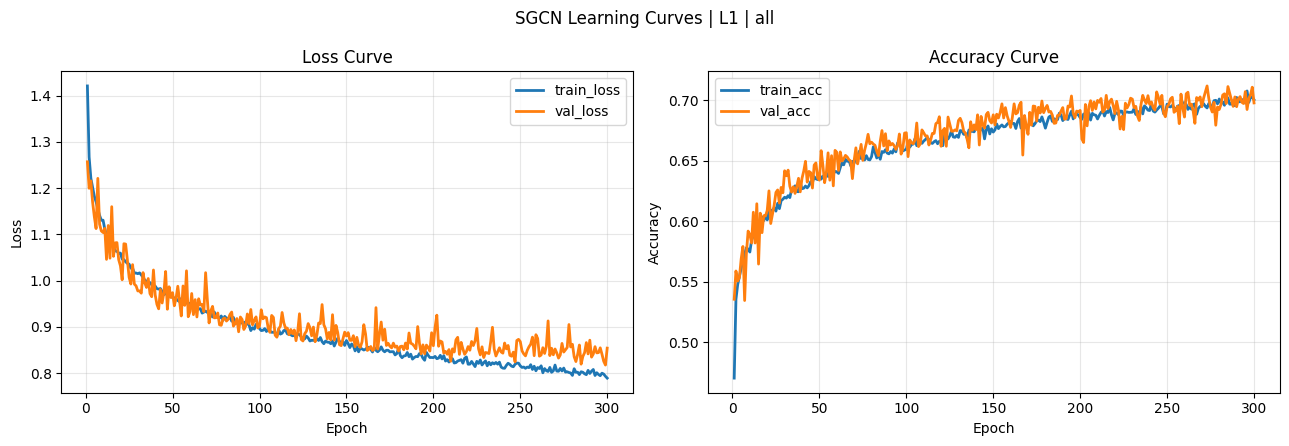

Fit check: No strong over/underfitting signal from final epoch gap. gap=+0.0026
Saved: checkpoints/sgcn_paper/L1_all_last.pt
Saved: checkpoints/sgcn_paper/L1_all_best.pt
Saved: plots/sgcn_paper/L1_all_curves.png

Run result:
{'level': 'L1', 'case': 'all', 'best_val_acc': 0.7116930256676173, 'best_epoch': 273, 'test_acc': 0.7074217951339195, 'test_f1': 0.5827460518740389, 'checkpoint_last': 'checkpoints/sgcn_paper/L1_all_last.pt', 'checkpoint_best': 'checkpoints/sgcn_paper/L1_all_best.pt', 'curve_png': 'plots/sgcn_paper/L1_all_curves.png'}


In [2]:
# Self-contained resume-capable SGCN training + checkpoints + learning curves
# ------------------------------------------------------------------------
# This cell can run independently (no dependency on previous notebook cells).

from pathlib import Path
from copy import deepcopy
from functools import lru_cache

import numpy as np
import pandas as pd
import scipy.sparse as sp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

import matplotlib.pyplot as plt


# -------------------------
# Reproducibility + device
# -------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# -------------------------
# Data paths
# -------------------------
ROOT = Path("FGVD_Graph_Handover")
META_PATH = ROOT / "metadata.csv"
ADJ_PATH = ROOT / "master_grid_adj.npz"
FEAT_ROOT = ROOT / "raw_features"

if not META_PATH.exists():
    raise FileNotFoundError(f"Missing metadata: {META_PATH}")
if not ADJ_PATH.exists():
    raise FileNotFoundError(f"Missing adjacency: {ADJ_PATH}")

metadata = pd.read_csv(META_PATH)
for c in ["vehicle_id", "split", "L1", "L2", "L3"]:
    metadata[c] = metadata[c].astype(str).str.strip()

print("Rows:", len(metadata))
print("Split counts:", metadata["split"].value_counts().to_dict())

# master adjacency (same for all samples)
adj_sparse = sp.load_npz(ADJ_PATH).tocoo()
edge_index = torch.tensor(np.vstack([adj_sparse.row, adj_sparse.col]), dtype=torch.long)
edge_attr = torch.tensor(adj_sparse.data, dtype=torch.float32)
print("Adj shape:", adj_sparse.shape, "| edges:", edge_index.shape[1])


# -------------------------
# Label levels and cases
# -------------------------
LEVEL_FEATURES = {
    "L1": ("rgb", "gabor", "sobel"),
    "L2": ("rgb", "gabor"),
    "L3": ("rgb", "gabor"),
}

TW_SET = {"motorcycle", "scooter"}
THW_SET = {"autorickshaw", "auto", "threewheeler", "three_wheeler"}


def norm_l1(x: str) -> str:
    return str(x).strip().lower().replace("-", "").replace(" ", "")


def build_level_labels(df: pd.DataFrame, level: str) -> np.ndarray:
    if level == "L1":
        return df["L1"].to_numpy(dtype=object)
    if level == "L2":
        return (df["L1"] + "::" + df["L2"]).to_numpy(dtype=object)
    if level == "L3":
        return (df["L1"] + "::" + df["L2"] + "::" + df["L3"]).to_numpy(dtype=object)
    raise ValueError("level must be L1/L2/L3")


def apply_case(df: pd.DataFrame, base_labels: np.ndarray, level: str, case_name: str):
    l1_norm = df["L1"].map(norm_l1).to_numpy()
    is_tw = np.isin(l1_norm, list(TW_SET))
    is_thw = np.isin(l1_norm, list(THW_SET))
    is_car = l1_norm == "car"

    if case_name == "all":
        keep = np.ones(len(df), dtype=bool)
        return base_labels, keep

    if case_name == "tw_vs_car":
        keep = is_tw | is_car
        return base_labels[keep], keep

    if case_name == "tw_vs_all":
        if level == "L1":
            y = np.where(is_tw, "two_wheeler", "other")
        else:
            y = np.where(is_tw, base_labels, "other")
        keep = np.ones(len(df), dtype=bool)
        return y, keep

    if case_name == "thw_vs_all":
        if level == "L1":
            y = np.where(is_thw, "three_wheeler", "other")
        else:
            y = np.where(is_thw, base_labels, "other")
        keep = np.ones(len(df), dtype=bool)
        return y, keep

    if case_name == "tw_thw_vs_all":
        group = is_tw | is_thw
        if level == "L1":
            y = np.where(group, "two_or_three_wheeler", "other")
        else:
            y = np.where(group, base_labels, "other")
        keep = np.ones(len(df), dtype=bool)
        return y, keep

    raise ValueError(f"Unknown case_name: {case_name}")


# -------------------------
# Feature loading
# -------------------------
@lru_cache(maxsize=8000)
def _load_feature(vehicle_id: str, split: str, feat: str):
    p = FEAT_ROOT / feat / split / f"{vehicle_id}.npy"
    if not p.exists():
        raise FileNotFoundError(f"Missing feature file: {p}")
    return np.load(p).astype(np.float32)


def load_stacked_features(vehicle_id: str, split: str, feature_names):
    parts = [_load_feature(vehicle_id, split, feat) for feat in feature_names]
    return np.concatenate(parts, axis=1)


# -------------------------
# Dataset / model / epoch
# -------------------------
class FGVDGraphDataset(torch.utils.data.Dataset):
    def __init__(self, df: pd.DataFrame, y_encoded: np.ndarray, feature_names):
        self.df = df.reset_index(drop=True)
        self.y = y_encoded
        self.feature_names = tuple(feature_names)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = load_stacked_features(row["vehicle_id"], row["split"], self.feature_names)
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(int(self.y[idx]), dtype=torch.long)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)


class SGCNLayer(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.5):
        super().__init__()
        self.conv = GCNConv(in_channels, out_channels, add_self_loops=True, normalize=True)
        self.bn = nn.BatchNorm1d(out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr=None):
        x = self.conv(x, edge_index, edge_weight=edge_attr)
        x = self.bn(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x


class SGCN(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, hidden_dim: int = 64, num_layers: int = 2, dropout: float = 0.5):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(
                SGCNLayer(
                    in_channels if i == 0 else hidden_dim,
                    hidden_dim,
                    dropout=dropout,
                )
            )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_attr = getattr(data, "edge_attr", None)
        batch = getattr(data, "batch", None)

        for layer in self.layers:
            x = layer(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)
        return self.classifier(x)


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    preds_all, targets_all = [], []

    for batch in loader:
        batch = batch.to(device)
        targets = batch.y.view(-1)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(batch)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * targets.size(0)
        preds = logits.argmax(dim=1)
        preds_all.extend(preds.detach().cpu().numpy().tolist())
        targets_all.extend(targets.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(targets_all, preds_all)
    macro_f1 = f1_score(targets_all, preds_all, average="macro")
    return avg_loss, acc, macro_f1, np.asarray(preds_all), np.asarray(targets_all)


# -------------------------
# Experiment preparation
# -------------------------
def _tag(level: str, case_name: str) -> str:
    return f"{level}_{case_name}".replace("/", "_").replace(" ", "_")


def prepare_experiment(level: str, case_name: str, batch_size: int = 32, num_workers: int = 0):
    train_df = metadata[metadata["split"] == "train"].copy()
    val_df = metadata[metadata["split"] == "val"].copy()
    test_df = metadata[metadata["split"] == "test"].copy()

    y_train_base = build_level_labels(train_df, level)
    y_val_base = build_level_labels(val_df, level)
    y_test_base = build_level_labels(test_df, level)

    y_train_raw, keep_train = apply_case(train_df, y_train_base, level, case_name)
    y_val_raw, keep_val = apply_case(val_df, y_val_base, level, case_name)
    y_test_raw, keep_test = apply_case(test_df, y_test_base, level, case_name)

    train_df = train_df.loc[keep_train].reset_index(drop=True)
    val_df = val_df.loc[keep_val].reset_index(drop=True)
    test_df = test_df.loc[keep_test].reset_index(drop=True)

    le = LabelEncoder()
    le.fit(np.concatenate([y_train_raw, y_val_raw, y_test_raw]))

    y_train = le.transform(y_train_raw)
    y_val = le.transform(y_val_raw)
    y_test = le.transform(y_test_raw)

    feature_names = LEVEL_FEATURES[level]
    train_dataset = FGVDGraphDataset(train_df, y_train, feature_names)
    val_dataset = FGVDGraphDataset(val_df, y_val, feature_names)
    test_dataset = FGVDGraphDataset(test_df, y_test, feature_names)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return {
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "label_encoder": le,
        "train_count": len(train_df),
        "val_count": len(val_df),
        "test_count": len(test_df),
        "num_classes": len(le.classes_),
    }


# -------------------------
# Plotting
# -------------------------
def plot_learning_curves(history: dict, title: str, out_path: Path):
    epochs = history["epoch"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, history["train_loss"], label="train_loss", linewidth=2)
    axes[0].plot(epochs, history["val_loss"], label="val_loss", linewidth=2)
    axes[0].set_title("Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="train_acc", linewidth=2)
    axes[1].plot(epochs, history["val_acc"], label="val_acc", linewidth=2)
    axes[1].set_title("Accuracy Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


# -------------------------
# Main fit function
# -------------------------
def fit_with_resume(
    level: str = "L1",
    case_name: str = "all",
    additional_epochs: int = 20,
    target_total_epochs: int = None,
    resume: bool = True,
    clear_old_checkpoints: bool = False,
    batch_size: int = 32,
    hidden_dim: int = 64,
    num_layers: int = 2,
    dropout: float = 0.5,
    lr: float = 1e-3,
    num_workers: int = 0,
    print_every: int = 5,
):
    ckpt_root = Path("checkpoints/sgcn_paper")
    plot_root = Path("plots/sgcn_paper")
    ckpt_root.mkdir(parents=True, exist_ok=True)
    plot_root.mkdir(parents=True, exist_ok=True)

    tag = _tag(level, case_name)
    last_ckpt = ckpt_root / f"{tag}_last.pt"
    best_ckpt = ckpt_root / f"{tag}_best.pt"
    curve_png = plot_root / f"{tag}_curves.png"

    if clear_old_checkpoints:
        if last_ckpt.exists():
            last_ckpt.unlink()
        if best_ckpt.exists():
            best_ckpt.unlink()

    exp = prepare_experiment(level, case_name, batch_size=batch_size, num_workers=num_workers)
    print(f"\nRunning {level} | {case_name}")
    print(f"Samples: train={exp['train_count']}, val={exp['val_count']}, test={exp['test_count']}")
    print(f"Classes: {exp['num_classes']}")

    in_channels = 8 if level == "L1" else 7
    model = SGCN(
        in_channels=in_channels,
        num_classes=exp["num_classes"],
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": [],
    }

    start_epoch = 1
    best_val_acc = -1.0
    best_epoch = 0
    best_model_state = None

    if resume and last_ckpt.exists():
        ckpt = torch.load(last_ckpt, map_location="cpu")
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        history = ckpt.get("history", history)
        start_epoch = int(ckpt.get("epoch", 0)) + 1
        best_val_acc = float(ckpt.get("best_val_acc", -1.0))
        best_epoch = int(ckpt.get("best_epoch", 0))
        best_model_state = ckpt.get("best_model_state_dict", None)

        saved_classes = ckpt.get("label_classes", [])
        current_classes = exp["label_encoder"].classes_.tolist()
        if saved_classes and saved_classes != current_classes:
            raise RuntimeError("Label encoding changed since checkpoint creation. Cannot safely resume.")

        print(f"Resumed from checkpoint: {last_ckpt}")
        print(f"Restarting at epoch {start_epoch}")

    if target_total_epochs is not None:
        end_epoch = int(target_total_epochs)
    else:
        end_epoch = start_epoch + int(additional_epochs) - 1

    if start_epoch > end_epoch:
        print("No new epochs requested. Evaluating current best model.")
    else:
        for epoch in range(start_epoch, end_epoch + 1):
            tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, exp["train_loader"], criterion, optimizer)
            va_loss, va_acc, va_f1, _, _ = run_epoch(model, exp["val_loader"], criterion, optimizer=None)

            history["epoch"].append(epoch)
            history["train_loss"].append(float(tr_loss))
            history["val_loss"].append(float(va_loss))
            history["train_acc"].append(float(tr_acc))
            history["val_acc"].append(float(va_acc))
            history["train_f1"].append(float(tr_f1))
            history["val_f1"].append(float(va_f1))

            if va_acc > best_val_acc:
                best_val_acc = float(va_acc)
                best_epoch = int(epoch)
                best_model_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

                torch.save(
                    {
                        "epoch": epoch,
                        "best_epoch": best_epoch,
                        "best_val_acc": best_val_acc,
                        "best_model_state_dict": best_model_state,
                        "history": history,
                        "label_classes": exp["label_encoder"].classes_.tolist(),
                    },
                    best_ckpt,
                )

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_epoch": best_epoch,
                    "best_val_acc": best_val_acc,
                    "best_model_state_dict": best_model_state,
                    "history": history,
                    "label_classes": exp["label_encoder"].classes_.tolist(),
                },
                last_ckpt,
            )

            if epoch == start_epoch or epoch % print_every == 0 or epoch == end_epoch:
                print(
                    f"Epoch {epoch:03d} | "
                    f"train_acc={tr_acc:.4f} val_acc={va_acc:.4f} | "
                    f"train_loss={tr_loss:.4f} val_loss={va_loss:.4f}"
                )

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    te_loss, te_acc, te_f1, te_pred, te_true = run_epoch(model, exp["test_loader"], criterion, optimizer=None)

    pred_labels = exp["label_encoder"].inverse_transform(te_pred.astype(int))
    true_labels = exp["label_encoder"].inverse_transform(te_true.astype(int))

    print("\nFinal test metrics (best validation-accuracy checkpoint):")
    print(f"test_acc={te_acc:.4f} | test_f1={te_f1:.4f} | test_loss={te_loss:.4f}")
    print(classification_report(true_labels, pred_labels, digits=4))

    title = f"SGCN Learning Curves | {level} | {case_name}"
    plot_learning_curves(history, title=title, out_path=curve_png)

    if history["train_acc"]:
        gap = history["train_acc"][-1] - history["val_acc"][-1]
        if history["train_acc"][-1] < 0.70 and history["val_acc"][-1] < 0.70:
            fit_note = "Possible underfitting (both train/val accuracy are low)."
        elif gap > 0.08:
            fit_note = "Possible overfitting (train-val accuracy gap is high)."
        else:
            fit_note = "No strong over/underfitting signal from final epoch gap."
        print(f"Fit check: {fit_note} gap={gap:+.4f}")

    print(f"Saved: {last_ckpt}")
    print(f"Saved: {best_ckpt}")
    print(f"Saved: {curve_png}")

    return {
        "level": level,
        "case": case_name,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "test_acc": float(te_acc),
        "test_f1": float(te_f1),
        "checkpoint_last": str(last_ckpt),
        "checkpoint_best": str(best_ckpt),
        "curve_png": str(curve_png),
    }


# -------------------------
# USER CONTROLS
# -------------------------
LEVEL_TO_RUN = "L1"
CASE_TO_RUN = "all"         # all, tw_vs_all, thw_vs_all, tw_thw_vs_all, tw_vs_car
RESUME = False               # False => start fresh
CLEAR_OLD_CHECKPOINTS = True # delete previous checkpoint files for this level/case
ADDITIONAL_EPOCHS = 300      # used when TARGET_TOTAL_EPOCHS is None
TARGET_TOTAL_EPOCHS = 300    # exact total epochs target

result = fit_with_resume(
    level=LEVEL_TO_RUN,
    case_name=CASE_TO_RUN,
    additional_epochs=ADDITIONAL_EPOCHS,
    target_total_epochs=TARGET_TOTAL_EPOCHS,
    resume=RESUME,
    clear_old_checkpoints=CLEAR_OLD_CHECKPOINTS,
    batch_size=32,
    hidden_dim=64,
    num_layers=2,
    dropout=0.5,
    lr=1e-3,
    num_workers=0,
    print_every=5,
)

print("\nRun result:")
print(result)

Using device: cuda
Rows: 24450
Split counts: {'train': 15702, 'test': 4891, 'val': 3857}
Adj shape: (4096, 4096) | edges: 32004

Running L1 | all
Samples: train=15702, val=3857, test=4891
Classes: 7
Resumed from checkpoint: checkpoints/sgcn_paper/L1_all_last.pt
Restarting at epoch 201
Epoch 201 | train_acc=0.6873 val_acc=0.7034 | train_loss=0.8350 val_loss=0.8418
Epoch 205 | train_acc=0.6869 val_acc=0.6897 | train_loss=0.8297 val_loss=0.8664
Epoch 210 | train_acc=0.6834 val_acc=0.7011 | train_loss=0.8379 val_loss=0.8370
Epoch 215 | train_acc=0.6881 val_acc=0.6928 | train_loss=0.8250 val_loss=0.8592
Epoch 220 | train_acc=0.6872 val_acc=0.6954 | train_loss=0.8255 val_loss=0.8639
Epoch 225 | train_acc=0.6911 val_acc=0.6751 | train_loss=0.8220 val_loss=0.8759
Epoch 230 | train_acc=0.6911 val_acc=0.7008 | train_loss=0.8244 val_loss=0.8351
Epoch 235 | train_acc=0.6895 val_acc=0.6938 | train_loss=0.8216 val_loss=0.8494
Epoch 240 | train_acc=0.6917 val_acc=0.7050 | train_loss=0.8202 val_loss=0

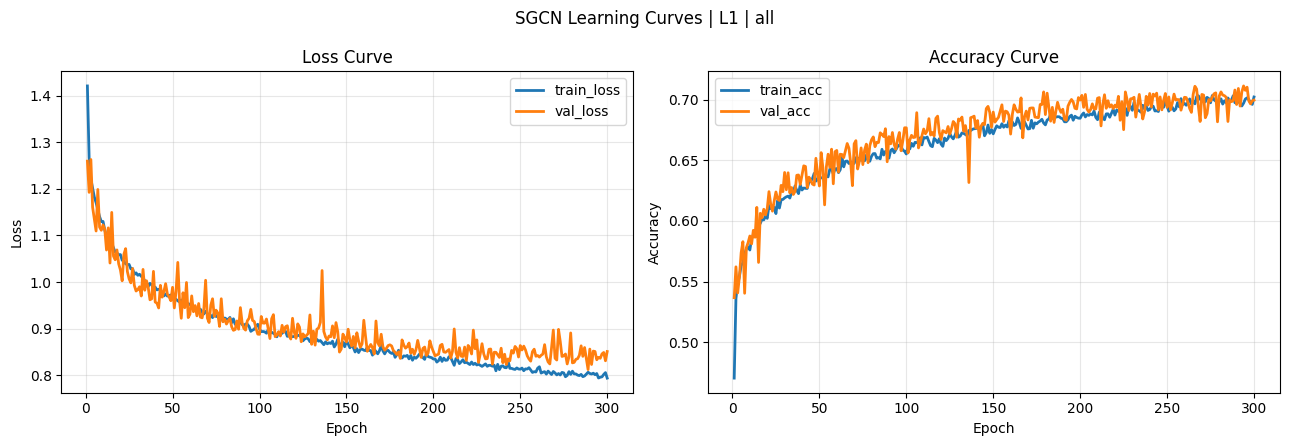

Fit check: No strong over/underfitting signal from final epoch gap. gap=+0.0026
Saved: checkpoints/sgcn_paper/L1_all_last.pt
Saved: checkpoints/sgcn_paper/L1_all_best.pt
Saved: plots/sgcn_paper/L1_all_curves.png

Run result:
{'level': 'L1', 'case': 'all', 'best_val_acc': 0.711174487943998, 'best_epoch': 294, 'test_acc': 0.7092619096299325, 'test_f1': 0.5770024402119937, 'checkpoint_last': 'checkpoints/sgcn_paper/L1_all_last.pt', 'checkpoint_best': 'checkpoints/sgcn_paper/L1_all_best.pt', 'curve_png': 'plots/sgcn_paper/L1_all_curves.png'}


In [3]:
# Self-contained resume-capable SGCN training + checkpoints + learning curves
# -----`-------------------------------------------------------------------
# This cell can run independently (no dependency on previous notebook cells).

from pathlib import Path
from copy import deepcopy
from functools import lru_cache

import numpy as np
import pandas as pd
import scipy.sparse as sp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

import matplotlib.pyplot as plt


# -------------------------
# Reproducibility + device
# -------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# -------------------------
# Data paths
# -------------------------
ROOT = Path("FGVD_Graph_Handover")
META_PATH = ROOT / "metadata.csv"
ADJ_PATH = ROOT / "master_grid_adj.npz"
FEAT_ROOT = ROOT / "raw_features"

if not META_PATH.exists():
    raise FileNotFoundError(f"Missing metadata: {META_PATH}")
if not ADJ_PATH.exists():
    raise FileNotFoundError(f"Missing adjacency: {ADJ_PATH}")

metadata = pd.read_csv(META_PATH)
for c in ["vehicle_id", "split", "L1", "L2", "L3"]:
    metadata[c] = metadata[c].astype(str).str.strip()

print("Rows:", len(metadata))
print("Split counts:", metadata["split"].value_counts().to_dict())

# master adjacency (same for all samples)
adj_sparse = sp.load_npz(ADJ_PATH).tocoo()
edge_index = torch.tensor(np.vstack([adj_sparse.row, adj_sparse.col]), dtype=torch.long)
edge_attr = torch.tensor(adj_sparse.data, dtype=torch.float32)
print("Adj shape:", adj_sparse.shape, "| edges:", edge_index.shape[1])


# -------------------------
# Label levels and cases
# -------------------------
LEVEL_FEATURES = {
    "L1": ("rgb", "gabor", "sobel"),
    "L2": ("rgb", "gabor"),
    "L3": ("rgb", "gabor"),
}

TW_SET = {"motorcycle", "scooter"}
THW_SET = {"autorickshaw", "auto", "threewheeler", "three_wheeler"}


def norm_l1(x: str) -> str:
    return str(x).strip().lower().replace("-", "").replace(" ", "")


def build_level_labels(df: pd.DataFrame, level: str) -> np.ndarray:
    if level == "L1":
        return df["L1"].to_numpy(dtype=object)
    if level == "L2":
        return (df["L1"] + "::" + df["L2"]).to_numpy(dtype=object)
    if level == "L3":
        return (df["L1"] + "::" + df["L2"] + "::" + df["L3"]).to_numpy(dtype=object)
    raise ValueError("level must be L1/L2/L3")


def apply_case(df: pd.DataFrame, base_labels: np.ndarray, level: str, case_name: str):
    l1_norm = df["L1"].map(norm_l1).to_numpy()
    is_tw = np.isin(l1_norm, list(TW_SET))
    is_thw = np.isin(l1_norm, list(THW_SET))
    is_car = l1_norm == "car"

    if case_name == "all":
        keep = np.ones(len(df), dtype=bool)
        return base_labels, keep

    if case_name == "tw_vs_car":
        keep = is_tw | is_car
        return base_labels[keep], keep

    if case_name == "tw_vs_all":
        if level == "L1":
            y = np.where(is_tw, "two_wheeler", "other")
        else:
            y = np.where(is_tw, base_labels, "other")
        keep = np.ones(len(df), dtype=bool)
        return y, keep

    if case_name == "thw_vs_all":
        if level == "L1":
            y = np.where(is_thw, "three_wheeler", "other")
        else:
            y = np.where(is_thw, base_labels, "other")
        keep = np.ones(len(df), dtype=bool)
        return y, keep

    if case_name == "tw_thw_vs_all":
        group = is_tw | is_thw
        if level == "L1":
            y = np.where(group, "two_or_three_wheeler", "other")
        else:
            y = np.where(group, base_labels, "other")
        keep = np.ones(len(df), dtype=bool)
        return y, keep

    raise ValueError(f"Unknown case_name: {case_name}")


# -------------------------
# Feature loading
# -------------------------
@lru_cache(maxsize=8000)
def _load_feature(vehicle_id: str, split: str, feat: str):
    p = FEAT_ROOT / feat / split / f"{vehicle_id}.npy"
    if not p.exists():
        raise FileNotFoundError(f"Missing feature file: {p}")
    return np.load(p).astype(np.float32)


def load_stacked_features(vehicle_id: str, split: str, feature_names):
    parts = [_load_feature(vehicle_id, split, feat) for feat in feature_names]
    return np.concatenate(parts, axis=1)


# -------------------------
# Dataset / model / epoch
# -------------------------
class FGVDGraphDataset(torch.utils.data.Dataset):
    def __init__(self, df: pd.DataFrame, y_encoded: np.ndarray, feature_names):
        self.df = df.reset_index(drop=True)
        self.y = y_encoded
        self.feature_names = tuple(feature_names)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = load_stacked_features(row["vehicle_id"], row["split"], self.feature_names)
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(int(self.y[idx]), dtype=torch.long)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)


class SGCNLayer(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.5):
        super().__init__()
        self.conv = GCNConv(in_channels, out_channels, add_self_loops=True, normalize=True)
        self.bn = nn.BatchNorm1d(out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr=None):
        x = self.conv(x, edge_index, edge_weight=edge_attr)
        x = self.bn(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x


class SGCN(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, hidden_dim: int = 64, num_layers: int = 2, dropout: float = 0.5):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(
                SGCNLayer(
                    in_channels if i == 0 else hidden_dim,
                    hidden_dim,
                    dropout=dropout,
                )
            )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_attr = getattr(data, "edge_attr", None)
        batch = getattr(data, "batch", None)

        for layer in self.layers:
            x = layer(x, edge_index, edge_attr)

        x = global_mean_pool(x, batch)
        return self.classifier(x)


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    preds_all, targets_all = [], []

    for batch in loader:
        batch = batch.to(device)
        targets = batch.y.view(-1)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(batch)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * targets.size(0)
        preds = logits.argmax(dim=1)
        preds_all.extend(preds.detach().cpu().numpy().tolist())
        targets_all.extend(targets.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(targets_all, preds_all)
    macro_f1 = f1_score(targets_all, preds_all, average="macro")
    return avg_loss, acc, macro_f1, np.asarray(preds_all), np.asarray(targets_all)


# -------------------------
# Experiment preparation
# -------------------------
def _tag(level: str, case_name: str) -> str:
    return f"{level}_{case_name}".replace("/", "_").replace(" ", "_")


def prepare_experiment(level: str, case_name: str, batch_size: int = 32, num_workers: int = 0):
    train_df = metadata[metadata["split"] == "train"].copy()
    val_df = metadata[metadata["split"] == "val"].copy()
    test_df = metadata[metadata["split"] == "test"].copy()

    y_train_base = build_level_labels(train_df, level)
    y_val_base = build_level_labels(val_df, level)
    y_test_base = build_level_labels(test_df, level)

    y_train_raw, keep_train = apply_case(train_df, y_train_base, level, case_name)
    y_val_raw, keep_val = apply_case(val_df, y_val_base, level, case_name)
    y_test_raw, keep_test = apply_case(test_df, y_test_base, level, case_name)

    train_df = train_df.loc[keep_train].reset_index(drop=True)
    val_df = val_df.loc[keep_val].reset_index(drop=True)
    test_df = test_df.loc[keep_test].reset_index(drop=True)

    le = LabelEncoder()
    le.fit(np.concatenate([y_train_raw, y_val_raw, y_test_raw]))

    y_train = le.transform(y_train_raw)
    y_val = le.transform(y_val_raw)
    y_test = le.transform(y_test_raw)

    feature_names = LEVEL_FEATURES[level]
    train_dataset = FGVDGraphDataset(train_df, y_train, feature_names)
    val_dataset = FGVDGraphDataset(val_df, y_val, feature_names)
    test_dataset = FGVDGraphDataset(test_df, y_test, feature_names)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return {
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "label_encoder": le,
        "train_count": len(train_df),
        "val_count": len(val_df),
        "test_count": len(test_df),
        "num_classes": len(le.classes_),
    }


# -------------------------
# Plotting
# -------------------------
def plot_learning_curves(history: dict, title: str, out_path: Path):
    epochs = history["epoch"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, history["train_loss"], label="train_loss", linewidth=2)
    axes[0].plot(epochs, history["val_loss"], label="val_loss", linewidth=2)
    axes[0].set_title("Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="train_acc", linewidth=2)
    axes[1].plot(epochs, history["val_acc"], label="val_acc", linewidth=2)
    axes[1].set_title("Accuracy Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


# -------------------------
# Main fit function
# -------------------------
def fit_with_resume(
    level: str = "L1",
    case_name: str = "all",
    additional_epochs: int = 20,
    target_total_epochs: int = None,
    resume: bool = True,
    clear_old_checkpoints: bool = False,
    batch_size: int = 32,
    hidden_dim: int = 64,
    num_layers: int = 2,
    dropout: float = 0.5,
    lr: float = 1e-3,
    num_workers: int = 0,
    print_every: int = 5,
):
    ckpt_root = Path("checkpoints/sgcn_paper")
    plot_root = Path("plots/sgcn_paper")
    ckpt_root.mkdir(parents=True, exist_ok=True)
    plot_root.mkdir(parents=True, exist_ok=True)

    tag = _tag(level, case_name)
    last_ckpt = ckpt_root / f"{tag}_last.pt"
    best_ckpt = ckpt_root / f"{tag}_best.pt"
    curve_png = plot_root / f"{tag}_curves.png"

    if clear_old_checkpoints:
        if last_ckpt.exists():
            last_ckpt.unlink()
        if best_ckpt.exists():
            best_ckpt.unlink()

    exp = prepare_experiment(level, case_name, batch_size=batch_size, num_workers=num_workers)
    print(f"\nRunning {level} | {case_name}")
    print(f"Samples: train={exp['train_count']}, val={exp['val_count']}, test={exp['test_count']}")
    print(f"Classes: {exp['num_classes']}")

    in_channels = 8 if level == "L1" else 7
    model = SGCN(
        in_channels=in_channels,
        num_classes=exp["num_classes"],
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": [],
    }

    start_epoch = 1
    best_val_acc = -1.0
    best_epoch = 0
    best_model_state = None

    if resume and last_ckpt.exists():
        ckpt = torch.load(last_ckpt, map_location="cpu")
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        history = ckpt.get("history", history)
        start_epoch = int(ckpt.get("epoch", 0)) + 1
        best_val_acc = float(ckpt.get("best_val_acc", -1.0))
        best_epoch = int(ckpt.get("best_epoch", 0))
        best_model_state = ckpt.get("best_model_state_dict", None)

        saved_classes = ckpt.get("label_classes", [])
        current_classes = exp["label_encoder"].classes_.tolist()
        if saved_classes and saved_classes != current_classes:
            raise RuntimeError("Label encoding changed since checkpoint creation. Cannot safely resume.")

        print(f"Resumed from checkpoint: {last_ckpt}")
        print(f"Restarting at epoch {start_epoch}")

    if target_total_epochs is not None:
        end_epoch = int(target_total_epochs)
    else:
        end_epoch = start_epoch + int(additional_epochs) - 1

    if start_epoch > end_epoch:
        print("No new epochs requested. Evaluating current best model.")
    else:
        for epoch in range(start_epoch, end_epoch + 1):
            tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, exp["train_loader"], criterion, optimizer)
            va_loss, va_acc, va_f1, _, _ = run_epoch(model, exp["val_loader"], criterion, optimizer=None)

            history["epoch"].append(epoch)
            history["train_loss"].append(float(tr_loss))
            history["val_loss"].append(float(va_loss))
            history["train_acc"].append(float(tr_acc))
            history["val_acc"].append(float(va_acc))
            history["train_f1"].append(float(tr_f1))
            history["val_f1"].append(float(va_f1))

            if va_acc > best_val_acc:
                best_val_acc = float(va_acc)
                best_epoch = int(epoch)
                best_model_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

                torch.save(
                    {
                        "epoch": epoch,
                        "best_epoch": best_epoch,
                        "best_val_acc": best_val_acc,
                        "best_model_state_dict": best_model_state,
                        "history": history,
                        "label_classes": exp["label_encoder"].classes_.tolist(),
                    },
                    best_ckpt,
                )

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_epoch": best_epoch,
                    "best_val_acc": best_val_acc,
                    "best_model_state_dict": best_model_state,
                    "history": history,
                    "label_classes": exp["label_encoder"].classes_.tolist(),
                },
                last_ckpt,
            )

            if epoch == start_epoch or epoch % print_every == 0 or epoch == end_epoch:
                print(
                    f"Epoch {epoch:03d} | "
                    f"train_acc={tr_acc:.4f} val_acc={va_acc:.4f} | "
                    f"train_loss={tr_loss:.4f} val_loss={va_loss:.4f}"
                )

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    te_loss, te_acc, te_f1, te_pred, te_true = run_epoch(model, exp["test_loader"], criterion, optimizer=None)

    pred_labels = exp["label_encoder"].inverse_transform(te_pred.astype(int))
    true_labels = exp["label_encoder"].inverse_transform(te_true.astype(int))

    print("\nFinal test metrics (best validation-accuracy checkpoint):")
    print(f"test_acc={te_acc:.4f} | test_f1={te_f1:.4f} | test_loss={te_loss:.4f}")
    print(classification_report(true_labels, pred_labels, digits=4))

    title = f"SGCN Learning Curves | {level} | {case_name}"
    plot_learning_curves(history, title=title, out_path=curve_png)

    if history["train_acc"]:
        gap = history["train_acc"][-1] - history["val_acc"][-1]
        if history["train_acc"][-1] < 0.70 and history["val_acc"][-1] < 0.70:
            fit_note = "Possible underfitting (both train/val accuracy are low)."
        elif gap > 0.08:
            fit_note = "Possible overfitting (train-val accuracy gap is high)."
        else:
            fit_note = "No strong over/underfitting signal from final epoch gap."
        print(f"Fit check: {fit_note} gap={gap:+.4f}")

    print(f"Saved: {last_ckpt}")
    print(f"Saved: {best_ckpt}")
    print(f"Saved: {curve_png}")

    return {
        "level": level,
        "case": case_name,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "test_acc": float(te_acc),
        "test_f1": float(te_f1),
        "checkpoint_last": str(last_ckpt),
        "checkpoint_best": str(best_ckpt),
        "curve_png": str(curve_png),
    }


# -------------------------
# USER CONTROLS
# -------------------------
LEVEL_TO_RUN = "L1"
CASE_TO_RUN = "all"         # all, tw_vs_all, thw_vs_all, tw_thw_vs_all, tw_vs_car
RESUME = True              # False => start fresh
CLEAR_OLD_CHECKPOINTS =  False # delete previous checkpoint files for this level/case
ADDITIONAL_EPOCHS = 100      # used when TARGET_TOTAL_EPOCHS is None
TARGET_TOTAL_EPOCHS = 300    # exact total epochs target

result = fit_with_resume(
    level=LEVEL_TO_RUN,
    case_name=CASE_TO_RUN,
    additional_epochs=ADDITIONAL_EPOCHS,
    target_total_epochs=TARGET_TOTAL_EPOCHS,
    resume=RESUME,
    clear_old_checkpoints=CLEAR_OLD_CHECKPOINTS,
    batch_size=32,
    hidden_dim=64,
    num_layers=2,
    dropout=0.5,
    lr=1e-3,
    num_workers=0,
    print_every=5,
)

print("\nRun result:")
print(result)

In [ ]:
# Paper-style multi-level SGCN runner
# Runs the full table-style set of experiments for L1, L2, and L3,
# and writes checkpoints to a separate folder so the existing resume cell
# stays untouched.

from pathlib import Path
from copy import deepcopy
from functools import lru_cache

import json
import numpy as np
import pandas as pd
import scipy.sparse as sp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

import matplotlib.pyplot as plt


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ROOT = Path("FGVD_Graph_Handover")
META_PATH = ROOT / "metadata.csv"
ADJ_PATH = ROOT / "master_grid_adj.npz"
FEAT_ROOT = ROOT / "raw_features"

metadata = pd.read_csv(META_PATH)
for col in ["vehicle_id", "split", "L1", "L2", "L3"]:
    metadata[col] = metadata[col].astype(str).str.strip()

adj_sparse = sp.load_npz(ADJ_PATH).tocoo()
edge_index = torch.tensor(np.vstack([adj_sparse.row, adj_sparse.col]), dtype=torch.long)
edge_attr = torch.tensor(adj_sparse.data, dtype=torch.float32)

LEVEL_FEATURES = {
    "L1": ("rgb", "gabor", "sobel"),
    "L2": ("rgb", "gabor"),
    "L3": ("rgb", "gabor"),
}

TW_SET = {"motorcycle", "scooter"}
THW_SET = {"autorickshaw", "auto", "threewheeler", "three_wheeler"}

LEGACY_L1_ROOT = Path("checkpoints/sgcn_paper")
NEW_ROOT = Path("checkpoints/sgcn_paper_multi_level")


def norm_l1(value: str) -> str:
    return str(value).strip().lower().replace("-", "").replace(" ", "")


def build_level_labels(df: pd.DataFrame, level: str) -> np.ndarray:
    if level == "L1":
        return df["L1"].to_numpy(dtype=object)
    if level == "L2":
        return (df["L1"] + "::" + df["L2"]).to_numpy(dtype=object)
    if level == "L3":
        return (df["L1"] + "::" + df["L2"] + "::" + df["L3"]).to_numpy(dtype=object)
    raise ValueError(f"Unknown level: {level}")


def apply_case(df: pd.DataFrame, base_labels: np.ndarray, level: str, case_name: str):
    l1_norm = df["L1"].map(norm_l1).to_numpy()
    is_tw = np.isin(l1_norm, list(TW_SET))
    is_thw = np.isin(l1_norm, list(THW_SET))
    is_car = l1_norm == "car"

    if case_name == "all":
        keep = np.ones(len(df), dtype=bool)
        return base_labels, keep

    if case_name == "tw_vs_all":
        if level == "L1":
            y = np.where(is_tw, "two_wheeler", "other")
        else:
            y = np.where(is_tw, base_labels, "other")
        return y, np.ones(len(df), dtype=bool)

    if case_name == "thw_vs_all":
        if level == "L1":
            y = np.where(is_thw, "three_wheeler", "other")
        else:
            y = np.where(is_thw, base_labels, "other")
        return y, np.ones(len(df), dtype=bool)

    if case_name == "tw_thw_vs_all":
        group = is_tw | is_thw
        if level == "L1":
            y = np.where(group, "two_or_three_wheeler", "other")
        else:
            y = np.where(group, base_labels, "other")
        return y, np.ones(len(df), dtype=bool)

    raise ValueError(f"Unknown case_name: {case_name}")


@lru_cache(maxsize=256)
def _load_feature(vehicle_id: str, split: str, feat: str):
    path = FEAT_ROOT / feat / split / f"{vehicle_id}.npy"
    if not path.exists():
        raise FileNotFoundError(f"Missing feature file: {path}")
    return np.load(path).astype(np.float32)


def load_stacked_features(vehicle_id: str, split: str, feature_names):
    return np.concatenate([_load_feature(vehicle_id, split, feat) for feat in feature_names], axis=1)


class FGVDGraphDataset(torch.utils.data.Dataset):
    def __init__(self, df: pd.DataFrame, y_encoded: np.ndarray, feature_names):
        self.df = df.reset_index(drop=True)
        self.y = y_encoded
        self.feature_names = tuple(feature_names)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = load_stacked_features(row["vehicle_id"], row["split"], self.feature_names)
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(int(self.y[idx]), dtype=torch.long)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)


class SGCNLayer(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.5):
        super().__init__()
        self.conv = GCNConv(in_channels, out_channels, add_self_loops=True, normalize=True)
        self.bn = nn.BatchNorm1d(out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr=None):
        x = self.conv(x, edge_index, edge_weight=edge_attr)
        x = self.bn(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x


class SGCN(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, hidden_dim: int = 64, num_layers: int = 2, dropout: float = 0.5):
        super().__init__()
        self.layers = nn.ModuleList()
        for layer_idx in range(num_layers):
            self.layers.append(
                SGCNLayer(
                    in_channels if layer_idx == 0 else hidden_dim,
                    hidden_dim,
                    dropout=dropout,
                )
            )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_attr = getattr(data, "edge_attr", None)
        batch = getattr(data, "batch", None)
        for layer in self.layers:
            x = layer(x, edge_index, edge_attr)
        x = global_mean_pool(x, batch)
        return self.classifier(x)


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    preds_all, targets_all = [], []

    for batch in loader:
        batch = batch.to(device)
        targets = batch.y.view(-1)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(batch)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * targets.size(0)
        preds = logits.argmax(dim=1)
        preds_all.extend(preds.detach().cpu().numpy().tolist())
        targets_all.extend(targets.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(targets_all, preds_all)
    macro_f1 = f1_score(targets_all, preds_all, average="macro")
    return avg_loss, acc, macro_f1, np.asarray(preds_all), np.asarray(targets_all)


def print_table(rows):
    header = f"{'Level':<4}  {'Case':<14}  {'Test Acc':>9}  {'Test F1':>9}  {'Classes':>7}"
    print("\n" + "=" * len(header))
    print(header)
    print("=" * len(header))
    for row in rows:
        print(f"{row['level']:<4}  {row['case']:<14}  {row['test_acc']*100:8.2f}%  {row['test_f1']*100:8.2f}%  {row['num_classes']:7d}")
    print("=" * len(header))


def checkpoint_dir(level: str, case_name: str) -> Path:
    if level == "L1":
        return LEGACY_L1_ROOT
    return NEW_ROOT / f"{level}_{case_name}"


def run_experiment(level: str, case_name: str):
    train_df = metadata[metadata["split"] == "train"].copy()
    val_df = metadata[metadata["split"] == "val"].copy()
    test_df = metadata[metadata["split"] == "test"].copy()

    y_train_base = build_level_labels(train_df, level)
    y_val_base = build_level_labels(val_df, level)
    y_test_base = build_level_labels(test_df, level)

    y_train_raw, keep_train = apply_case(train_df, y_train_base, level, case_name)
    y_val_raw, keep_val = apply_case(val_df, y_val_base, level, case_name)
    y_test_raw, keep_test = apply_case(test_df, y_test_base, level, case_name)

    train_df = train_df.loc[keep_train].reset_index(drop=True)
    val_df = val_df.loc[keep_val].reset_index(drop=True)
    test_df = test_df.loc[keep_test].reset_index(drop=True)

    le = LabelEncoder()
    le.fit(np.concatenate([y_train_raw, y_val_raw, y_test_raw]))

    y_train = le.transform(y_train_raw)
    y_val = le.transform(y_val_raw)
    y_test = le.transform(y_test_raw)

    feature_names = LEVEL_FEATURES[level]
    train_dataset = FGVDGraphDataset(train_df, y_train, feature_names)
    val_dataset = FGVDGraphDataset(val_df, y_val, feature_names)
    test_dataset = FGVDGraphDataset(test_df, y_test, feature_names)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

    in_channels = 8 if level == "L1" else 7
    model = SGCN(in_channels=in_channels, num_classes=len(le.classes_), hidden_dim=64, num_layers=2, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    best_state = None
    best_val_acc = -1.0
    history = []

    for epoch in range(1, 101):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc, va_f1, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)

        history.append({
            'epoch': epoch,
            'train_loss': tr_loss,
            'val_loss': va_loss,
            'train_acc': tr_acc,
            'val_acc': va_acc,
            'train_f1': tr_f1,
            'val_f1': va_f1,
        })

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = deepcopy(model.state_dict())

        if epoch == 1 or epoch % 5 == 0:
            print(f"Epoch {epoch:03d} | train acc {tr_acc:.4f} loss {tr_loss:.4f} | val acc {va_acc:.4f} loss {va_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    te_loss, te_acc, te_f1, te_pred, te_true = run_epoch(model, test_loader, criterion, optimizer=None)
    pred_labels = le.inverse_transform(te_pred.astype(int))
    true_labels = le.inverse_transform(te_true.astype(int))

    ckpt_dir = checkpoint_dir(level, case_name)
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    tag = f"{level}_{case_name}"

    torch.save({
        'level': level,
        'case_name': case_name,
        'model_state_dict': model.state_dict(),
        'best_state_dict': best_state,
        'label_classes': le.classes_.tolist(),
        'history': history,
        'test_acc': float(te_acc),
        'test_f1': float(te_f1),
    }, ckpt_dir / f"{tag}_best.pt")

    torch.save({
        'level': level,
        'case_name': case_name,
        'model_state_dict': model.state_dict(),
        'label_classes': le.classes_.tolist(),
        'history': history,
        'epoch': len(history),
    }, ckpt_dir / f"{tag}_last.pt")

    with open(ckpt_dir / f"{tag}_metrics.json", "w", encoding="utf-8") as f:
        json.dump({
            'level': level,
            'case_name': case_name,
            'test_acc': float(te_acc),
            'test_f1': float(te_f1),
            'num_classes': int(len(le.classes_)),
        }, f, indent=2)

    print(f"\n{level} | {case_name} test acc: {te_acc:.4f} | test f1: {te_f1:.4f}")
    print(classification_report(true_labels, pred_labels, digits=4))

    return {
        'level': level,
        'case': case_name,
        'test_acc': float(te_acc),
        'test_f1': float(te_f1),
        'num_classes': int(len(le.classes_)),
    }


output_root = NEW_ROOT
output_root.mkdir(parents=True, exist_ok=True)

experiments = [
    ('L1', 'tw_vs_all'),
    ('L1', 'thw_vs_all'),
    ('L1', 'tw_thw_vs_all'),
    ('L1', 'all'),
    ('L2', 'tw_vs_all'),
    ('L2', 'thw_vs_all'),
    ('L2', 'tw_thw_vs_all'),
    ('L2', 'all'),
    ('L3', 'tw_vs_all'),
    ('L3', 'thw_vs_all'),
    ('L3', 'tw_thw_vs_all'),
    ('L3', 'all'),
]

results = []
for level, case_name in experiments:
    try:
        results.append(run_experiment(level, case_name))
    except Exception as exc:
        print(f"FAILED [{level} | {case_name}]: {exc}")

print_table(results)

summary_path = output_root / 'summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2)

print(f"Saved summary to: {summary_path}")
print(f"Saved checkpoints under: {output_root}")

Using device: cuda
Epoch 001 | train acc 0.7368 loss 0.5213 | val acc 0.7807 loss 0.4605
Epoch 005 | train acc 0.8091 loss 0.4237 | val acc 0.6977 loss 0.5990
Epoch 010 | train acc 0.8236 loss 0.4015 | val acc 0.8325 loss 0.3734
Epoch 015 | train acc 0.8302 loss 0.3837 | val acc 0.8380 loss 0.3531
Epoch 020 | train acc 0.8379 loss 0.3681 | val acc 0.8250 loss 0.4105
Epoch 025 | train acc 0.8473 loss 0.3514 | val acc 0.7944 loss 0.4360
Epoch 030 | train acc 0.8521 loss 0.3435 | val acc 0.8660 loss 0.3121
Epoch 035 | train acc 0.8610 loss 0.3321 | val acc 0.8621 loss 0.3147
Epoch 040 | train acc 0.8667 loss 0.3218 | val acc 0.8753 loss 0.2947
Epoch 045 | train acc 0.8659 loss 0.3169 | val acc 0.8758 loss 0.2917
Epoch 050 | train acc 0.8687 loss 0.3125 | val acc 0.8724 loss 0.2909
Epoch 055 | train acc 0.8724 loss 0.3061 | val acc 0.8815 loss 0.2757
Epoch 060 | train acc 0.8756 loss 0.2977 | val acc 0.8864 loss 0.2801
Epoch 065 | train acc 0.8814 loss 0.2918 | val acc 0.8857 loss 0.2676
E